<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/ch1_sinusoidworld/Explaining_the_DFT_a_music_perspective_part8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform - Part 8
## Phasors or the value of thinking in circles

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.


In **Part 1** we looked at how we can create complex sounds by combining sinudoids of different frequencies and amplitudes that change over time (additive synthesis) such as the sound of a bell or even the infamous THX sound. We also can create plausible and recognizable music melodies and tunes that are similar to the chip tunes made by the early game machines and computer sound cards.

In **Part 2** we started looked at the inverse problem of analysis. Given an array of audio samples that correspond to a complex sound or a simple melody we would like to find what are the frequencies and amplitudes of each sinusoidal component. We started by the simple problem of amplitude estimation of a single sinusoid and looked at peak and RMS amplitude. These methods were not very accurate in the presence of interference so we looked a estimating the amplitude through a dot-product (correlation) with probe/basis sinusoid with unit amplitude and frequency equal to the frequency we were looking for. This approach was shown to be very robust to the presence of interference but does require knowledge of the frequency you are training to estimate the amplitude for as well as phase alignment between the probe/basis and the target sinusoid.

In **Part 3** we looked at how we can deal with time and phase. For time we can perform short-time processing in which we process the audio samples in small chunks that are long enough to contain a few cycles of the sinusoids we are intrested in but short enough to allow us to estimate amplitudes that change over time.

To estimate the amplitude accurately when the probe/basis signal and the target sinusoid are not aligned in time we can calculate multiple amplitude estimate for different time shifts and select the maximum amplitude estimate as our amplitude estimate. This approach is called cross-correlation and is a fundamental digital signal processing operation with direct equivalents in mamallian auditory systems. It is a computationally costly operation as multiple dot-products need to be computed and the accuracy of the estimation depends on how many time shits are considered. It can also work for other waveforms than sinusoids. However, if we are dealing with sinusoids there is a much more efficient, clever way to estimate the amplitude.

If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency. The resulting two ampltitude estimates can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.

In **Part 4** we looked at how this basis/probe pair of a unit amplitude sine array of samples and a unit amplitude cosine array of samples form an amplitude and phase estimator for a particular frequency. By creating a linearly-spaced grid of frequencies we can create a transform that can change the representation of our signal from the time-domain to the frequency domain. The frequency domain (or spectrum) specifies how we can re-synthesize/re-construct our original time-domain signal by appropriately combining sinusoids with the estimated dot-product amplitudes with the two basis/probe signals from each frequency. These can be converted to actual amplitude and phase. To re-synthesize the sinusoidal components from the frequency domain we do not need to recompute samples of the sine and cosine function but can simply weigh each probe/basis appropriately and add them together. We called this the Discrete Probe Transform and showed that it can perform perfect reconstruction i.e we can get back our original input signal from the spectrum (frequency domain) without any loss of information. The Discrete Probe transform is essentially the Discrete Fourier Transform (DFT).

In **part 5** we formalize the DFT and start introducing some cool mathematical notation. The pair of basis/probes amplitude/phase estimator for a specific frequency is the basic building block and the key to understanding the DFT.


In **part 6** we look at how we can use the Discrete Fourier Transform for some cool audio applications namely spectral processing and spectrum/spectrogram visualizations.




In **part 7** we revisit the equations describing the Discrete Fourier Transform and sinusoids and explain in more detail the complex number notation that is typically used in Digitial Signal Processign textbooks and papers. In **part 8** We introduce the idea of a **phasors**, a rotating vector at constant speed and show how **complex numbers** can help simplify the notation of for phasors, make calculations much simpler, and provide geometric intitution about concepts such as the addition of sinusoids of the same frequency but different amplitudes and phases, aliasing, and negative frequencies. This part is a bit more mathematical and historical but hopefully it will inspire you to learn more about the topic and not be mystified by DSP equations with **complex numbers** any more.

In [ ]:
import librosa
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import logging

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()


# Phasors

## The value of thinking in circles

We can think of any sinusoidal signal as a vector of a specific length rotating at constant speed. Let's take a snapshot of that vector. That snapshot is a specific complex number. To keep things simple let's assume the rotating vector has unit length. The snapshot will be a complex number also with unit length. Let's say that it is at an angle $\theta$. What happens if we multiply that complex number with itself. The length of the vector will remain the same as it is the product of the unit legth with itself. The angle of the new vector (complex number) will be $2 \theta$. If we multiply it again we will have $3 \theta$ and so forth. We can write this sequence of snapshots as $W, W^2, W^3$. Any position of the vector corrseponds to a particular angle so we can write the complex numbers as a **function** of the angle $\theta$.

$$
E(\theta) = \cos(\theta) + j \sin(\theta) = 1 \angle \theta
$$

The derivative of $E(\theta)$ with respect to $\theta$ is:
$$
\frac{dE(\theta)}{d\theta} = -\sin(\theta) + j \cos(\theta) = jE(\theta)
$$

So the function $E(\theta)$ representing the rotating vector has the property that it's derivative with respect to $\theta$ is the same function multiplied by a constant in this case a complex number. In real-valued calculus that is the exponential function and with skipping some of the mathematical details this also holds for complex numbers. Therefore we can write the function:
$$
E(\theta) = e^{j\theta}
$$
Now we can write this as
$$
\cos \theta + jsin \theta = e^{j \theta}
$$

This is considered one of the most important remarkable formulas in mathematics called Euler's formula after the Swiss mathematician Leonhard Euler (1707-1783). It expresses the idea that a constant speed rotating vector (that arises from simply harmonic motion in physics) can be represented as a fixed complex number raised to higher and higher powers. Practically it allows us to reduce the amount of writing we have to do without have to always write explicitly the sine and cosine functions. When using this notation and standard algebra the interpretation complex number multiplication as the product of the mangitude and the sum of the angles holds because of the rules for multiplying exponents.

$$
z_1 \cdot z_2 = R_1 e^{j\theta1} \cdot R_2 e^{j\theta2} = R_1 R_2 e^{j (\theta1 + \theta_2)}
$$


When the angle is changing over time we can write our sinusoid as:
$$
e^{j\omega t}
$$
with $\omega$ being the frequency in radians.

> A PHASOR IS A VECTOR ROTATING AT CONSTANT SPEED

The animation with sound below shows viusally how phasors rotate and the corresponding time-domain cosine and sine signals resulting from projecting the vector on each coordinate axis. It also shows how adding phasors can create more complex sounds (additive synthesis).

In [ ]:
from IPython.display import Video, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.io import wavfile


def generate_phasor_animation(
    frequencies, amplitudes=None, duration_per_stage=4.0, sample_rate=44100
):
    """Generates a 2x2 grid animation and audio where frequencies are introduced

    incrementally: starting with the first for two cycles, then adding the next,
    and so on.
    """
    n_phasors = len(frequencies)
    if amplitudes is None:
        amplitudes = [1.0] * n_phasors

    # Determine timing per stage based on the first frequency's period (2 full cycles)
    f_base = frequencies[0]
    period = 1.0 / f_base if f_base > 0 else 2.0
    stage_duration = 2.0 * period  # 2 cycles for the first frequency
    total_duration = stage_duration * n_phasors

    # 1. Audio Generation (summing audio components over the total timeline)
    t_audio = np.linspace(
        0, total_duration, int(sample_rate * total_duration), endpoint=False
    )
    combined_audio = np.zeros_like(t_audio)

    for i in range(n_phasors):
        # Audio active from the start of its introduced stage to the end
        start_t = i * stage_duration
        freq = frequencies[i]
        amp = amplitudes[i]
        audio_freq = freq * 440.0 if freq < 10 else freq

        mask = t_audio >= start_t
        combined_audio[mask] += amp * np.sin(
            2 * np.pi * audio_freq * (t_audio[mask] - start_t)
        )

    combined_audio_int16 = np.int16(
        combined_audio / np.max(np.abs(combined_audio)) * 32767
    )
    audio_filename = "phasor_sound.wav"
    wavfile.write(audio_filename, sample_rate, combined_audio_int16)

    # 2. Setup Plot Animation in a 2x2 Equal Grid
    fps = 30
    num_frames = int(fps * total_duration)
    t_vis = np.linspace(0, total_duration, num_frames)

    max_limit = float(sum(amplitudes) * 1.2)

    fig, axes = plt.subplots(
        2, 2, figsize=(10, 10), gridspec_kw={"width_ratios": [1, 1]}
    )
    ((ax_phasor, ax_sin), (ax_cos, ax_info)) = axes

    # --- Top-Left Panel: Phasors (Complex Plane) ---
    ax_phasor.set_xlim(-max_limit, max_limit)
    ax_phasor.set_ylim(-max_limit, max_limit)
    ax_phasor.set_aspect("equal")
    ax_phasor.axhline(0, color="gray", lw=0.8)
    ax_phasor.axvline(0, color="gray", lw=0.8)
    ax_phasor.set_title(
        "Phasors (Incremental Introduction)", fontsize=11, fontweight="bold"
    )
    ax_phasor.set_xlabel("Re (Cosine)")
    ax_phasor.set_ylabel("Im (Sine)")

    running_radius = 0.0
    for amp in amplitudes:
        running_radius += amp
        circle = plt.Circle(
            (0, 0),
            running_radius,
            color="lightgray",
            fill=False,
            lw=1.2,
            ls="--",
        )
        ax_phasor.add_patch(circle)

    colors = ["r", "g", "b", "c", "m", "y", "orange"]
    phasor_lines = []
    for i in range(n_phasors):
        c = colors[i % len(colors)]
        (line,) = ax_phasor.plot(
            [],
            [],
            f"{c}-o",
            lw=2,
            label=f"Phasor {i+1} (f={frequencies[i]}, A={amplitudes[i]})",
        )
        phasor_lines.append(line)

    (sum_line,) = ax_phasor.plot(
        [], [], "purple", lw=2.5, ls="--", label="Sum Vector"
    )
    ax_phasor.legend(loc="upper right", fontsize=8)

    # --- Top-Right Panel: Sine Waveform (Imaginary Part) ---
    ax_sin.set_xlim(0, total_duration)
    ax_sin.set_ylim(-max_limit, max_limit)
    ax_sin.axhline(0, color="gray", lw=0.8)
    ax_sin.set_title("Sine (Imaginary Part)", fontsize=11, fontweight="bold")
    ax_sin.set_xlabel("Time (s)")
    ax_sin.set_ylabel("Amplitude")
    ax_sin.grid(True, alpha=0.3)

    (sin_wave_line,) = ax_sin.plot(
        [], [], "blue", lw=2, label="Incremental Sum of Sines"
    )
    (curr_sin_point,) = ax_sin.plot([], [], "bo", ms=7)
    ax_sin.legend(loc="upper right", fontsize=8)

    # --- Bottom-Left Panel: Cosine Waveform (Real Part) ---
    ax_cos.set_xlim(0, total_duration)
    ax_cos.set_ylim(-max_limit, max_limit)
    ax_cos.axhline(0, color="gray", lw=0.8)
    ax_cos.set_title("Cosine (Real Part)", fontsize=11, fontweight="bold")
    ax_cos.set_xlabel("Time (s)")
    ax_cos.set_ylabel("Amplitude")
    ax_cos.grid(True, alpha=0.3)

    (cos_wave_line,) = ax_cos.plot(
        [], [], "darkorange", lw=2, label="Incremental Sum of Cosines"
    )
    (curr_cos_point,) = ax_cos.plot([], [], "o", color="darkorange", ms=7)
    ax_cos.legend(loc="upper right", fontsize=8)

    # --- Bottom-Right Panel: Text Info Block ---
    ax_info.axis("off")
    info_lines = ["PHASOR CONFIGURATION", "─────────────────────"]
    for i, (f, a) in enumerate(zip(frequencies, amplitudes)):
        info_lines.append(f"• Component {i+1} (Stage {i+1}):")
        info_lines.append(f"  - Freq (ω): {f}")
        info_lines.append(f"  - Amplitude: {a}")
    info_text = "\n".join(info_lines)

    ax_info.text(
        0.1,
        0.85,
        info_text,
        transform=ax_info.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#cccccc"
        ),
    )

    def init():
        for line in phasor_lines:
            line.set_data([], [])
        sum_line.set_data([], [])
        cos_wave_line.set_data([], [])
        curr_cos_point.set_data([], [])
        sin_wave_line.set_data([], [])
        curr_sin_point.set_data([], [])
        return (
            *phasor_lines,
            sum_line,
            cos_wave_line,
            curr_cos_point,
            sin_wave_line,
            curr_sin_point,
        )

    def update(frame):
        current_t = float(t_vis[frame])

        # Determine how many phasors are active at current_t
        active_count = min(
            n_phasors, int(current_t // stage_duration) + 1
        )

        coords_x = [0.0]
        coords_y = [0.0]
        curr_x, curr_y = 0.0, 0.0

        for i in range(n_phasors):
            line = phasor_lines[i]
            if i < active_count:
                f = frequencies[i]
                a = amplitudes[i]
                # Reset phase alignment when a phasor is introduced so it starts smoothly
                start_t = i * stage_duration
                local_t = current_t - start_t
                angle = 2 * np.pi * f * local_t

                next_x = curr_x + float(a * np.cos(angle))
                next_y = curr_y + float(a * np.sin(angle))
                coords_x.append(next_x)
                coords_y.append(next_y)
                curr_x, curr_y = next_x, next_y

                line.set_data(
                    [coords_x[i], coords_x[i + 1]],
                    [coords_y[i], coords_y[i + 1]],
                )
            else:
                # Keep inactive phasors hidden/collapsed at the origin or previous point
                line.set_data([], [])

        if active_count > 0:
            sum_line.set_data([0.0, coords_x[-1]], [0.0, coords_y[-1]])
        else:
            sum_line.set_data([], [])

        # Calculate wave histories incrementally up to the current frame
        wave_t = t_vis[: frame + 1]
        cos_y_vals = np.zeros_like(wave_t)
        sin_y_vals = np.zeros_like(wave_t)

        for i in range(n_phasors):
            start_t = i * stage_duration
            f = frequencies[i]
            a = amplitudes[i]

            # Contribution is active only after its introduction time
            mask = wave_t >= start_t
            if np.any(mask):
                local_wave_t = wave_t[mask] - start_t
                cos_y_vals[mask] += a * np.cos(2 * np.pi * f * local_wave_t)
                sin_y_vals[mask] += a * np.sin(2 * np.pi * f * local_wave_t)

        cos_wave_line.set_data(wave_t, cos_y_vals)
        curr_cos_point.set_data([current_t], [coords_x[-1] if active_count > 0 else 0.0])

        sin_wave_line.set_data(wave_t, sin_y_vals)
        curr_sin_point.set_data([current_t], [coords_y[-1] if active_count > 0 else 0.0])

        return (
            *phasor_lines,
            sum_line,
            cos_wave_line,
            curr_cos_point,
            sin_wave_line,
            curr_sin_point,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_silent = "phasor_silent_incremental.mp4"
    anim.save(video_silent, writer="ffmpeg", fps=fps)

    final_video = "phasor_incremental_with_sound.mp4"
    os.system(
        f"ffmpeg -y -i {video_silent} -i {audio_filename} -c:v copy -c:a aac -b:a 192k {final_video}"
    )

    display(Video(final_video, embed=True))


# Example usage: starts with frequency 0.5 for two cycles, then adds 1.0, then 2.0
generate_phasor_animation(
    frequencies=[0.5, 1.0, 2.0], amplitudes=[1.0, 0.7, 0.4]
)

# Adding sinusoids of the same frequency but different phase and amplitudes

An important property of sinusoids is that if we add two sinusoids of the same frequency but different phases and amplitudes the result is another sinusoid of the **same** frequency.

When looking at time domain plots this property is not obvious as you can see in the plot. The sum is clearly the same frequency but if you were to look only at the bottom left plot showing the sinusoids that are added super-imposed would you think that the result is not only a sinusoid but also with the same frequency.  




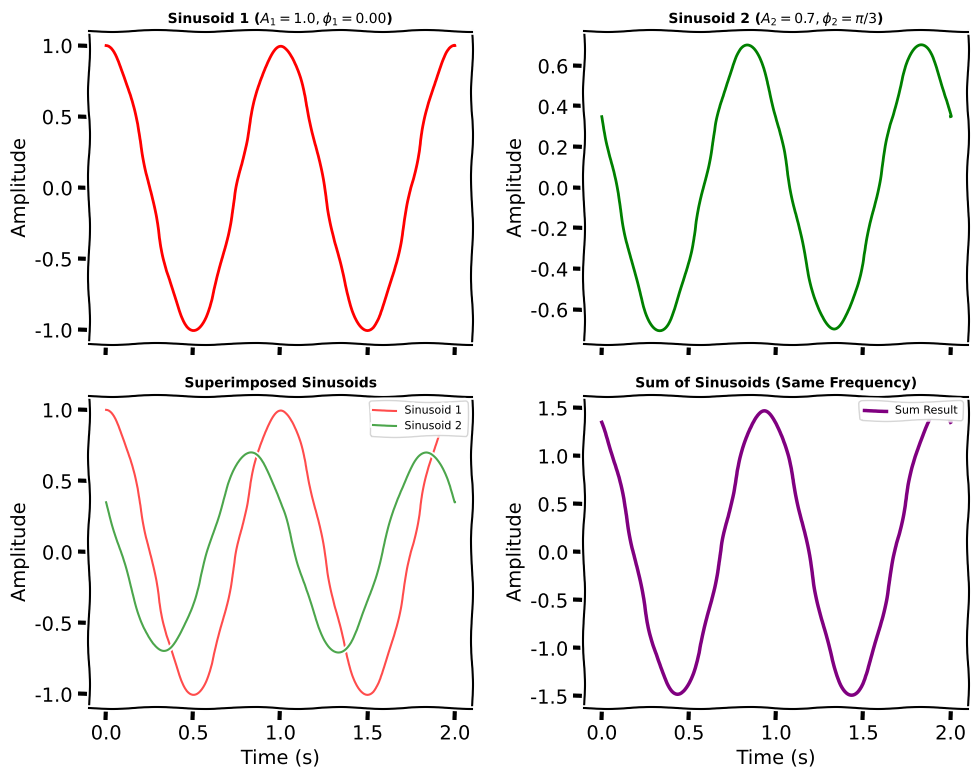

In [ ]:

# Parameters
frequency = 1.0  # Shared frequency (Hz)
duration = 2.0  # Duration in seconds
num_points = 500
t = np.linspace(0, duration, num_points)

# Component 1: Amplitude 1.0, Phase 0.0
A1 = 1.0
phi1 = 0.0
y1 = A1 * np.cos(2 * np.pi * frequency * t + phi1)

# Component 2: Amplitude 0.7, Phase pi/3
A2 = 0.7
phi2 = np.pi / 3
y2 = A2 * np.cos(2 * np.pi * frequency * t + phi2)

# Sum of the two sinusoids
y_sum = y1 + y2

# Setup 2x2 Subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
((ax1, ax2), (ax3, ax4)) = axes

# --- Top-Left: Sinusoid 1 ---
ax1.plot(t, y1, color="red", lw=2)
ax1.set_title(
    f"Sinusoid 1 ($A_1={A1}, \\phi_1={phi1:.2f}$)",
    fontsize=10,
    fontweight="bold",
)
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# --- Top-Right: Sinusoid 2 ---
ax2.plot(t, y2, color="green", lw=2)
ax2.set_title(
    f"Sinusoid 2 ($A_2={A2}, \\phi_2=\\pi/3$)", fontsize=10, fontweight="bold"
)
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

# --- Bottom-Left: Superimposed ---
ax3.plot(t, y1, color="red", lw=1.5, alpha=0.7, label="Sinusoid 1")
ax3.plot(t, y2, color="green", lw=1.5, alpha=0.7, label="Sinusoid 2")
ax3.set_title("Superimposed Sinusoids", fontsize=10, fontweight="bold")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Amplitude")
ax3.legend(loc="upper right", fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Bottom-Right: Sum ---
ax4.plot(t, y_sum, color="purple", lw=2.5, label="Sum Result")
ax4.set_title(
    "Sum of Sinusoids (Same Frequency)", fontsize=10, fontweight="bold"
)
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Amplitude")
ax4.legend(loc="upper right", fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We can try to show this property using algebra:
$$
 a_1 \cos(\omega t + \phi_1) + a_2 \cos(\omega t + \phi_2)
$$

The derivation is a a bit of a slog and would require using the trigonometric formulas for cosine and sine of sums:
$$
\begin{align}
\cos(\theta + \phi) = cos(\theta)cos(\phi) - sin(\theta)sin(\phi) \\
\sin(\theta + \phi) = sin(\theta)cos(\phi) + cos(\theta)sin(\phi) \\
\end{align}
$$

If you enjoy algebraic derivations go ahead and do it but we will see that using phasors there is a much more intuitive way of thinking about it.
Each sinusoid is a phasor rotating at constant speed. As they have different phases there is an angle between them but because they have the same frequency they rotate together. Their sum is found by the parallelogram law for each location and therefore will rotate together with them as if the whole thing was welded together. The animation below visually show this.

In [ ]:
from IPython.display import Video, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import os


def generate_parallelogram_phasor_animation(
    A1=1.0, phi1=0.0, A2=0.7, phi2=np.pi / 3, duration=4.0, sample_rate=44100
):
    """Generates an animation demonstrating that the sum of two phasors with the

    same frequency but different amplitudes and phases rotates together as a
    rigid body, showing the rotating parallelogram law with dashed lines.
    """
    freq = 0.5  # Rotation frequency (Hz)
    omega = 2 * np.pi * freq

    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = (A1 + A2) * 1.3

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.set_xlim(-max_limit, max_limit)
    ax.set_ylim(-max_limit, max_limit)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(
        "Rigid Parallelogram Law (Same Frequency Sum)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Re (Cosine)")
    ax.set_ylabel("Im (Sine)")

    # Reference circles for bounds
    circle1 = plt.Circle(
        (0, 0), A1, color="lightgray", fill=False, lw=1, ls=":"
    )
    ax.add_patch(circle1)

    # Plot handles
    (phasor1_line,) = ax.plot([], [], "r-o", lw=2, label=f"Phasor 1 ($A_1={A1}$)")
    (phasor2_line,) = ax.plot(
        [], [], "g-o", lw=2, label=f"Phasor 2 ($A_2={A2}$)"
    )
    (sum_line,) = ax.plot([], [], "purple", lw=2.5, ls="-", label="Sum Vector")

    # Parallelogram dashed construction lines
    (para_line1,) = ax.plot(
        [], [], color="green", linestyle="--", alpha=0.6, lw=1.5
    )
    (para_line2,) = ax.plot(
        [], [], color="red", linestyle="--", alpha=0.6, lw=1.5
    )

    ax.legend(loc="upper right", fontsize=9)

    def init():
        phasor1_line.set_data([], [])
        phasor2_line.set_data([], [])
        sum_line.set_data([], [])
        para_line1.set_data([], [])
        para_line2.set_data([], [])
        return (
            phasor1_line,
            phasor2_line,
            sum_line,
            para_line1,
            para_line2,
        )

    def update(frame):
        current_t = float(t_vis[frame])

        # Base rotation angle common to both
        theta = omega * current_t

        # Tip of Phasor 1
        angle1 = theta + phi1
        x1 = float(A1 * np.cos(angle1))
        y1 = float(A1 * np.sin(angle1))

        # Tip of Phasor 2 starting from origin (for parallelogram construction)
        angle2 = theta + phi2
        x2_orig = float(A2 * np.cos(angle2))
        y2_orig = float(A2 * np.sin(angle2))

        # Tip of Phasor 2 attached tip-to-tail
        x_sum = x1 + x2_orig
        y_sum = y1 + y2_orig

        # Set individual vectors
        phasor1_line.set_data([0.0, x1], [0.0, y1])
        phasor2_line.set_data([0.0, x2_orig], [0.0, y2_orig])  # shown from origin for parallelogram view
        sum_line.set_data([0.0, x_sum], [0.0, y_sum])

        # Parallelogram dashed lines connecting tips
        para_line1.set_data([x1, x_sum], [y1, y_sum])
        para_line2.set_data([x2_orig, x_sum], [y2_orig, y_sum])

        return (
            phasor1_line,
            phasor2_line,
            sum_line,
            para_line1,
            para_line2,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_filename = "parallelogram_phasor.mp4"
    anim.save(video_filename, writer="ffmpeg", fps=fps)

    display(Video(video_filename, embed=True))


generate_parallelogram_phasor_animation()


This is also much easier to prove using phasor notation.
$$
X_1 = A_1 e^{j(\omega t+\phi_1)} \\
X_2 = A_2 e^{j(\omega t+\phi_2)} \\
X_{sum} = X_1 + X_2 = A_1 e^{j(\omega t+\phi_1)} + A_2 e^{j(\omega t+\phi_2)} \\
X_{sum} = (A_1 e^{j(\phi_1)} + A_2 e^{j(\phi_2)})e^{j(\omega t)} \\
X_{sum} = A_{sum} e^{j (\omega t + \phi_{sum})}
$$
By factoring out the frequency term we get a constant complex number. The notation power of the exponentials and the phasor notation makes this a much easier derivation than doing the messy trigonometry algebra.

# Sampling and Aliasing

We have already discussed that in order for computers to process analog signals such as general audio, speech, and music the signal is discretized in time **sampling** and the values at each sampling position are discretized in space.

Let's think about sampling in terms of rotating phasors. Suppose as it rotates continuously we take snapshots and label them with integers. If we sample fast compared to the frequency of the phasor, the dots will be closely spaced and progressing counter-clockwise around the circle. In this case the sample capture reasonably the true frequency of the phasor.


In [ ]:

def generate_sampling_phasor_animation():
    """Generates an animation of a single phasor rotating by pi/16 every second
    for 5 steps, labeling the tip with increasing integers (0, 1, 2, 3, 4)
    and drawing dashed grey lines for all preceding phasor positions.
    """
    duration = 5.0  # 5 seconds total (1 second per step)
    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = 1.5

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-max_limit, max_limit)
    ax.set_ylim(-max_limit, max_limit)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(
        "Phasor Sampling ($\pi/16$ per second)",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Re (Cosine)")
    ax.set_ylabel("Im (Sine)")

    circle = plt.Circle((0, 0), 1.0, color="lightgray", fill=False, lw=1.2, ls="--")
    ax.add_patch(circle)

    # Preceding dashed grey lines for past phasor positions (indices 0 to 3 max)
    history_lines = []
    for _ in range(4):
        (hline,) = ax.plot([], [], color="gray", linestyle="--", lw=1.2)
        history_lines.append(hline)

    (phasor_line,) = ax.plot([], [], "r-o", lw=2, label="Current Phasor")

    # Text annotations for the sample points
    sample_texts = []
    for _ in range(5):
        sample_texts.append(
            ax.text(
                0,
                0,
                "",
                fontsize=11,
                fontweight="bold",
                color="navy",
                ha="left",
                va="bottom",
            )
        )

    ax.legend(loc="upper right", fontsize=8)

    def init():
        phasor_line.set_data([], [])
        for hline in history_lines:
            hline.set_data([], [])
        for txt in sample_texts:
            txt.set_text("")
        return phasor_line, *history_lines, *sample_texts

    def update(frame):
        current_t = float(t_vis[frame])
        # Floor time to get discrete 1-second steps, capped at 4
        step = min(int(current_t), 4)

        # Angle increments by pi/16 every second
        angle = step * (np.pi / 16.0)

        x = float(np.cos(angle))
        y = float(np.sin(angle))

        phasor_line.set_data([0.0, x], [0.0, y])

        # Draw dashed grey lines for all preceding steps
        for i in range(4):
            if i < step:
                prev_angle = i * (np.pi / 16.0)
                px = float(np.cos(prev_angle))
                py = float(np.sin(prev_angle))
                history_lines[i].set_data([0.0, px], [0.0, py])
            else:
                history_lines[i].set_data([], [])

        # Reveal sample point labels up to the current step
        for i in range(5):
            if i <= step:
                sample_angle = i * (np.pi / 16.0)
                sx = float(np.cos(sample_angle))
                sy = float(np.sin(sample_angle))
                sample_texts[i].set_position(
                    (sx + 0.05, sy + 0.05)
                )  # slight offset for label
                sample_texts[i].set_text(str(i))
            else:
                sample_texts[i].set_text("")

        return phasor_line, *history_lines, *sample_texts

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_filename = "phasor_sampling_history.mp4"
    anim.save(video_filename, writer="ffmpeg", fps=fps)

    display(Video(video_filename, embed=True))


generate_sampling_phasor_animation()

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_993/2755303705.py:21: SyntaxWarning: invalid escape sequence '\p'
  "Phasor Sampling ($\pi/16$ per second)",


Now let's see what happens if we decrease the sampling rate. The dots will be spaced further and further apart until we only get two snapshots each cycle. This is the case when the frequency of the phasor/sinusoid is half the sampling rate - this is the absolute limit for having enough samples to capture a frequency.

In [ ]:

def generate_continuous_sampling_animation():
    """Generates an animation of a continuously rotating phasor where an

    increasing integer label appears at the tip whenever the phasor crosses
    0 and pi radians.
    """
    duration = 8.0  # 8 seconds total
    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = 1.5

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-max_limit, max_limit)
    ax.set_ylim(-max_limit, max_limit)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(
        "Continuous Phasor Rotation & Zero/Pi Sampling",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Re (Cosine)")
    ax.set_ylabel("Im (Sine)")

    circle = plt.Circle((0, 0), 1.0, color="lightgray", fill=False, lw=1.2, ls="--")
    ax.add_patch(circle)

    (phasor_line,) = ax.plot([], [], "r-o", lw=2, label="Rotating Phasor")

    # Storage for permanent sample labels at 0, pi, 2pi, etc.
    sample_texts = []
    sample_points_x = []
    sample_points_y = []
    (scatter_samples,) = ax.plot([], [], "ko", ms=4)

    ax.legend(loc="upper right", fontsize=8)

    # We want it to complete several half-rotations over the duration
    # Let's say omega = pi rad/sec (hits 0 and pi every 1 second)
    omega = np.pi

    def init():
        phasor_line.set_data([], [])
        scatter_samples.set_data([], [])
        return phasor_line, scatter_samples

    def update(frame):
        current_t = float(t_vis[frame])
        angle = omega * current_t

        x = float(np.cos(angle))
        y = float(np.sin(angle))

        phasor_line.set_data([0.0, x], [0.0, y])

        # Check for new half-rotation crossings (0, pi, 2pi, 3pi...)
        # We can track the expected count based on floor(angle / pi)
        current_count = int(np.floor(angle / np.pi))

        # Clear old texts and rebuild based on current count
        for txt in sample_texts:
            txt.remove()
        sample_texts.clear()
        sample_points_x.clear()
        sample_points_y.clear()

        for i in range(current_count + 1):
            sample_angle = i * np.pi
            sx = float(np.cos(sample_angle))
            sy = float(np.sin(sample_angle))
            sample_points_x.append(sx)
            sample_points_y.append(sy)
            txt = ax.text(
                sx + 0.05,
                sy + 0.05,
                str(i),
                fontsize=11,
                fontweight="bold",
                color="navy",
            )
            sample_texts.append(txt)

        scatter_samples.set_data(sample_points_x, sample_points_y)

        return phasor_line, scatter_samples

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=False,
    )
    plt.close(fig)

    video_filename = "continuous_phasor_sampling.mp4"
    anim.save(video_filename, writer="ffmpeg", fps=fps)

    display(Video(video_filename, embed=True))


generate_continuous_sampling_animation()

Let's see what happens if we sample at an even slower rate, so that the frequency of the phasor is a bit higher than half the sampling rate. The problem is that the resulting samples are indistinguishable from the result we would have obtained if the frequency of the phasor was the same bit lower than half the sampling rate with the phasor now rotaining clock-wise. The projection on the x-axis will be the same but the estimation of the phasor's frequency will be unclear.

The frequency corresponding to half the *sampling rate* is called the Nyquist frequency, named after the electricial engineer Harry Nyquist (1889-1976). The phenomenon of multiple frequencies resulting in the same samples is called *aliasing*. When using a particular sampling rate $\omega_s$ we can NOT distinguish the difference between any frequency $\omega_0$ and $\pm \omega_0 \pm \omega_s$ for all integers $k$. All these frequencies are aliases of each other. The phasor animations makes this phenomenon clear.


In [ ]:
from IPython.display import Video, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import os


def generate_offset_sampling_animation():
    """Generates an animation of a phasor that rotates by (pi/16 + pi) every

    second for 5 steps, labeling the tip with increasing integers (0, 1, 2, 3,
    4) and drawing dashed grey lines for preceding positions.
    """
    duration = 5.0  # 5 seconds total (1 second per step)
    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = 1.5

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-max_limit, max_limit)
    ax.set_ylim(-max_limit, max_limit)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(
        "Phasor Sampling ($\Delta\theta = \pi/16 + \pi$ per step)",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Re (Cosine)")
    ax.set_ylabel("Im (Sine)")

    circle = plt.Circle((0, 0), 1.0, color="lightgray", fill=False, lw=1.2, ls="--")
    ax.add_patch(circle)

    # Preceding dashed grey lines for past phasor positions (indices 0 to 3 max)
    history_lines = []
    for _ in range(4):
        (hline,) = ax.plot([], [], color="gray", linestyle="--", lw=1.2)
        history_lines.append(hline)

    (phasor_line,) = ax.plot([], [], "r-o", lw=2, label="Current Phasor")

    # Text annotations for the sample points
    sample_texts = []
    for _ in range(5):
        sample_texts.append(
            ax.text(
                0,
                0,
                "",
                fontsize=11,
                fontweight="bold",
                color="navy",
                ha="left",
                va="bottom",
            )
        )

    ax.legend(loc="upper right", fontsize=8)

    def init():
        phasor_line.set_data([], [])
        for hline in history_lines:
            hline.set_data([], [])
        for txt in sample_texts:
            txt.set_text("")
        return phasor_line, *history_lines, *sample_texts

    def update(frame):
        current_t = float(t_vis[frame])
        # Floor time to get discrete 1-second steps, capped at 4
        step = min(int(current_t), 4)

        # Angle increments by (pi/16 + pi) every second
        angle = step * (np.pi / 16.0 + np.pi)

        x = float(np.cos(angle))
        y = float(np.sin(angle))

        phasor_line.set_data([0.0, x], [0.0, y])

        # Draw dashed grey lines for all preceding steps
        for i in range(4):
            if i < step:
                prev_angle = i * (np.pi / 16.0 + np.pi)
                px = float(np.cos(prev_angle))
                py = float(np.sin(prev_angle))
                history_lines[i].set_data([0.0, px], [0.0, py])
            else:
                history_lines[i].set_data([], [])

        # Reveal sample point labels up to the current step
        for i in range(5):
            if i <= step:
                sample_angle = i * (np.pi / 16.0 + np.pi)
                sx = float(np.cos(sample_angle))
                sy = float(np.sin(sample_angle))
                sample_texts[i].set_position(
                    (sx + 0.05, sy + 0.05)
                )  # slight offset for label
                sample_texts[i].set_text(str(i))
            else:
                sample_texts[i].set_text("")

        return phasor_line, *history_lines, *sample_texts

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_filename = "phasor_sampling_offset.mp4"
    anim.save(video_filename, writer="ffmpeg", fps=fps)

    display(Video(video_filename, embed=True))


generate_offset_sampling_animation()

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_993/3302155209.py:29: SyntaxWarning: invalid escape sequence '\D'
  "Phasor Sampling ($\Delta\theta = \pi/16 + \pi$ per step)",


# Negative Frequencies

Another concept that becomes much more intuitive and easy to understand when using phasors is the idea of a negative frequency. We have seen that these frequencies arise at the definiton of the Discrete Fourier Transform and result in the "mirror" mangitude spectrum.

When thinking of a sinusoid as a phasor rotating at constant speed we get both a sine signals projected on the imaginary axis as well as a cosine signal projected on the real axis. If we add a phasor of the same frequency rotating clock-wise then the imaginary project cancel out and we get only a real-valued signal which is what we want in audio processing.

In [ ]:
from IPython.display import Video, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import os


def generate_clean_negative_frequency_animation(
    freq=1.0, duration=4.0, sample_rate=44100
):
    """Generates an animation demonstrating negative frequencies with two subplots:

    - Left: Complex plane showing positive (CCW) and negative (CW) frequency
      phasors starting from the origin, with a single real projection on the x-axis.
    - Right: Real projection waveform tracking the combined real component over time.
    """
    omega = 2 * np.pi * freq

    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = 2.5

    fig, (ax_phasor, ax_wave) = plt.subplots(
        1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 1]}
    )

    # --- Left Panel: Phasor Complex Plane ---
    ax_phasor.set_xlim(-max_limit, max_limit)
    ax_phasor.set_ylim(-max_limit, max_limit)
    ax_phasor.set_aspect("equal")
    ax_phasor.axhline(0, color="gray", lw=0.8)
    ax_phasor.axvline(0, color="gray", lw=0.8)
    ax_phasor.set_title(
        "Positive & Negative Freq (From Origin)",
        fontsize=11,
        fontweight="bold",
    )
    ax_phasor.set_xlabel("Re (Cosine)")
    ax_phasor.set_ylabel("Im (Sine)")

    circle1 = plt.Circle(
        (0, 0), 1.0, color="lightgray", fill=False, lw=1, ls=":"
    )
    ax_phasor.add_patch(circle1)

    (pos_phasor_line,) = ax_phasor.plot(
        [], [], "r-o", lw=2, label="Positive Freq (+ω, CCW)"
    )
    (neg_phasor_line,) = ax_phasor.plot(
        [], [], "g-o", lw=2, label="Negative Freq (-ω, CW)"
    )
    (sum_line,) = ax_phasor.plot(
        [], [], "purple", lw=2.5, ls="--", label="Real Sum (on x-axis)"
    )

    # Dashed vertical line dropping down to the real axis from the sum/tips
    (proj_line,) = ax_phasor.plot(
        [], [], color="purple", linestyle=":", alpha=0.6, lw=1.5
    )

    ax_phasor.legend(loc="upper right", fontsize=8)

    # --- Right Panel: Real Projection Waveform ---
    ax_wave.set_xlim(0, duration)
    ax_wave.set_ylim(-max_limit, max_limit)
    ax_wave.axhline(0, color="gray", lw=0.8)
    ax_wave.set_title(
        "Real Projection Sum", fontsize=11, fontweight="bold"
    )
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")
    ax_wave.grid(True, alpha=0.3)

    (wave_sum,) = ax_wave.plot(
        [], [], color="purple", lw=2.5, label="2cos(ωt) [Sum]"
    )
    (curr_point,) = ax_wave.plot([], [], "o", color="purple", ms=7)
    ax_wave.legend(loc="upper right", fontsize=8)

    def init():
        pos_phasor_line.set_data([], [])
        neg_phasor_line.set_data([], [])
        sum_line.set_data([], [])
        proj_line.set_data([], [])
        wave_sum.set_data([], [])
        curr_point.set_data([], [])
        return (
            pos_phasor_line,
            neg_phasor_line,
            sum_line,
            proj_line,
            wave_sum,
            curr_point,
        )

    def update(frame):
        current_t = float(t_vis[frame])

        # Positive frequency rotates counter-clockwise (+omega * t)
        angle_pos = omega * current_t
        x_pos = float(np.cos(angle_pos))
        y_pos = float(np.sin(angle_pos))

        # Negative frequency rotates clockwise (-omega * t)
        angle_neg = -omega * current_t
        x_neg = float(np.cos(angle_neg))
        y_neg = float(np.sin(angle_neg))

        # Sum vector on the real axis
        x_sum = x_pos + x_neg
        y_sum = 0.0

        # Both vectors start from the origin
        pos_phasor_line.set_data([0.0, x_pos], [0.0, y_pos])
        neg_phasor_line.set_data([0.0, x_neg], [0.0, y_neg])
        sum_line.set_data([0.0, x_sum], [0.0, y_sum])

        # Drop vertical line from the sum vector tip to the x-axis (or show total real position)
        proj_line.set_data([x_sum, x_sum], [0.0, y_pos + y_neg])

        # Update waveform history on the right (Only showing the real projection/sum)
        wave_t = t_vis[: frame + 1]
        y_w_sum = np.cos(omega * wave_t) + np.cos(-omega * wave_t)

        wave_sum.set_data(wave_t, y_w_sum)
        curr_point.set_data([current_t], [x_sum])

        return (
            pos_phasor_line,
            neg_phasor_line,
            sum_line,
            proj_line,
            wave_sum,
            curr_point,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_filename = "negative_frequency_clean.mp4"
    anim.save(video_filename, writer="ffmpeg", fps=fps)

    display(Video(video_filename, embed=True))


generate_clean_negative_frequency_animation()

# BEATING

The phenomenon of beats is that if we play two sinusoids that are close in frequency we get an interesting interference pattern. This happens because they shift in and out of phase with each other. This creates a pulsting variation in volume at a lower frequency. Musicians use beating (or more accurately it's elimination) as a way to tune instruments with adjustable tuning.

Here we take a look at beating from a **phasor perspective**.
We can write the sum of two beating phasors as:
$$
a_1 e^{j \omega t} + a_2 e^{j (\omega +\delta) t}
$$

You can visualize and hear beating with the animation below.

In [ ]:
from IPython.display import Video, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.io import wavfile


def generate_beats_with_waveform(
    f1=2.0, f2=2.2, duration=10.0, sample_rate=44100
):
    """Generates an animation with two subplots:

    - Left: Phasor beating (two close frequencies and their sum vector)
    - Right: Real projection (cosine wave) tracking the envelope over time
    """
    # 1. Audio Generation (summing two close frequencies)
    t_audio = np.linspace(
        0, duration, int(sample_rate * duration), endpoint=False
    )
    audio_f1 = 220.0
    audio_f2 = audio_f1 + (f2 - f1) * (220.0 / f1)

    audio_y1 = np.sin(2 * np.pi * audio_f1 * t_audio)
    audio_y2 = np.sin(2 * np.pi * audio_f2 * t_audio)
    combined_audio = audio_y1 + audio_y2

    combined_audio_int16 = np.int16(
        combined_audio / np.max(np.abs(combined_audio)) * 32767
    )
    audio_filename = "beats_sound.wav"
    wavfile.write(audio_filename, sample_rate, combined_audio_int16)

    # 2. Setup Plot Animation (1x2 Subplots: Phasor Plane & Real Projection)
    fps = 30
    num_frames = int(fps * duration)
    t_vis = np.linspace(0, duration, num_frames)

    max_limit = 2.5

    fig, (ax_phasor, ax_wave) = plt.subplots(
        1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 1]}
    )

    # --- Left Panel: Phasor Complex Plane ---
    ax_phasor.set_xlim(-max_limit, max_limit)
    ax_phasor.set_ylim(-max_limit, max_limit)
    ax_phasor.set_aspect("equal")
    ax_phasor.axhline(0, color="gray", lw=0.8)
    ax_phasor.axvline(0, color="gray", lw=0.8)
    ax_phasor.set_title(
        f"Phasor Beating (f₁ = {f1}, f₂ = {f2})",
        fontsize=11,
        fontweight="bold",
    )
    ax_phasor.set_xlabel("Re (Cosine)")
    ax_phasor.set_ylabel("Im (Sine)")

    circle_min = plt.Circle(
        (0, 0), 0.0, color="lightgray", fill=False, lw=1, ls=":"
    )
    circle_max = plt.Circle(
        (0, 0), 2.0, color="lightgray", fill=False, lw=1, ls=":"
    )
    ax_phasor.add_patch(circle_min)
    ax_phasor.add_patch(circle_max)

    (phasor1_line,) = ax_phasor.plot([], [], "r-o", lw=2, label="Phasor 1 (f₁)")
    (phasor2_line,) = ax_phasor.plot([], [], "g-o", lw=2, label="Phasor 2 (f₂)")
    (sum_line,) = ax_phasor.plot(
        [], [], "purple", lw=2.5, ls="--", label="Sum Vector"
    )
    ax_phasor.legend(loc="upper right", fontsize=8)

    # --- Right Panel: Real Projection & Envelope ---
    ax_wave.set_xlim(0, duration)
    ax_wave.set_ylim(-max_limit, max_limit)
    ax_wave.axhline(0, color="gray", lw=0.8)
    ax_wave.set_title("Real Projection (Envelope)", fontsize=11, fontweight="bold")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")
    ax_wave.grid(True, alpha=0.3)

    (wave_line,) = ax_wave.plot(
        [], [], "darkorange", lw=2, label="cos(ω₁t) + cos(ω₂t)"
    )
    (curr_point,) = ax_wave.plot([], [], "o", color="darkorange", ms=7)
    ax_wave.legend(loc="upper right", fontsize=8)

    def init():
        phasor1_line.set_data([], [])
        phasor2_line.set_data([], [])
        sum_line.set_data([], [])
        wave_line.set_data([], [])
        curr_point.set_data([], [])
        return (
            phasor1_line,
            phasor2_line,
            sum_line,
            wave_line,
            curr_point,
        )

    def update(frame):
        current_t = float(t_vis[frame])

        angle1 = 2 * np.pi * f1 * current_t
        angle2 = 2 * np.pi * f2 * current_t

        x1 = float(np.cos(angle1))
        y1 = float(np.sin(angle1))

        # Second phasor attached tip-to-tail
        x2 = x1 + float(np.cos(angle2))
        y2 = y1 + float(np.sin(angle2))

        phasor1_line.set_data([0.0, x1], [0.0, y1])
        phasor2_line.set_data([x1, x2], [y1, y2])
        sum_line.set_data([0.0, x2], [0.0, y2])

        # Update Wave history on the right
        wave_t = t_vis[: frame + 1]
        wave_y = np.cos(2 * np.pi * f1 * wave_t) + np.cos(
            2 * np.pi * f2 * wave_t
        )
        wave_line.set_data(wave_t, wave_y)
        curr_point.set_data([current_t], [x2])

        return (
            phasor1_line,
            phasor2_line,
            sum_line,
            wave_line,
            curr_point,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        init_func=init,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)

    video_silent = "beats_waveform_silent.mp4"
    anim.save(video_silent, writer="ffmpeg", fps=fps)

    final_video = "beats_waveform_with_sound.mp4"
    os.system(
        f"ffmpeg -y -i {video_silent} -i {audio_filename} -c:v copy -c:a aac -b:a 192k {final_video}"
    )

    display(Video(final_video, embed=True))


# Example usage:
generate_beats_with_waveform(f1=2.0, f2=2.2, duration=10.0)


# Summary


We have now covered the important idea of phasors (representing sinusoids as constantly rotating vectors counter-clockwise) and using complex number notation to simplify derivations and provide us with intuitive understanding of many Digital Signal Processing concepts such as sampling, aliasing, adding sinusoids of the same frequency, negative frequencies and beating.

Take a look at the Discrete Fourier Transform again and try to think of it as a linear sieve of phasors. Hopefully now the notation makes much more sense.

\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  = \sum_{t=0}^{N-1} x_t cos(tk2\pi/N) + \sum_{t=0}^{N-1} x_t  j sin(tk2\pi/N)
\end{equation}

In the next and final part of this exposition we will look into some implementation details and practical tips for using the DFT for music applications as well as some more theoretical concepts.

